In [1]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CreditCardFraudDetection") \
    .getOrCreate()

print("Spark Session Created Successfully!")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/23 13:22:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/23 13:22:29 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark Session Created Successfully!


In [2]:
from pyspark.sql.functions import lit

# Load Training Data
df_train = spark.read.csv("../data/fraudTrain.csv", header=True, inferSchema=True)

# Load Test Data
df_test = spark.read.csv("../data/fraudTest.csv", header=True, inferSchema=True)

# Add split column
df_train = df_train.withColumn("split", lit("train"))
df_test = df_test.withColumn("split", lit("test"))

# Combine both
df = df_train.union(df_test)

print("Data Loaded Successfully!")
print("Total Rows:", df.count())

Data Loaded Successfully!
Total Rows: 1852394


In [3]:
# Fraud vs Non-Fraud Count
fraud_count = df.groupBy("is_fraud").count().orderBy("is_fraud")
fraud_count.show()

+--------+-------+
|is_fraud|  count|
+--------+-------+
|       0|1842743|
|       1|   9651|
+--------+-------+



In [4]:
from pyspark.sql.functions import round, avg

# Fraud rate by category
fraud_by_category = df.groupBy("category") \
    .agg(round(avg("is_fraud") * 100, 2).alias("fraud_rate_%")) \
    .orderBy("fraud_rate_%", ascending=False)

fraud_by_category.show()

+--------------+------------+
|      category|fraud_rate_%|
+--------------+------------+
|  shopping_net|        1.59|
|      misc_net|         1.3|
|   grocery_pos|        1.26|
|  shopping_pos|        0.63|
| gas_transport|        0.41|
|      misc_pos|        0.28|
|        travel|        0.27|
|   grocery_net|        0.27|
| personal_care|        0.22|
| entertainment|        0.22|
|     kids_pets|        0.19|
|   food_dining|        0.16|
|health_fitness|        0.15|
|          home|        0.15|
+--------------+------------+



In [5]:
from pyspark.sql.functions import round, avg

# Fraud rate by gender
fraud_by_gender = df.groupBy("gender") \
    .agg(round(avg("is_fraud") * 100, 2).alias("fraud_rate_%")) \
    .orderBy("fraud_rate_%", ascending=False)

fraud_by_gender.show()

+------+------------+
|gender|fraud_rate_%|
+------+------------+
|     M|        0.57|
|     F|        0.48|
+------+------------+



In [6]:
# Fraud rate by state
fraud_by_state = df.groupBy("state") \
    .agg(round(avg("is_fraud") * 100, 2).alias("fraud_rate_%")) \
    .orderBy("fraud_rate_%", ascending=False)

fraud_by_state.show()

+-----+------------+
|state|fraud_rate_%|
+-----+------------+
|   DE|       100.0|
|   RI|        2.01|
|   AK|        1.69|
|   OR|        0.75|
|   NH|        0.67|
|   VA|        0.65|
|   TN|        0.64|
|   NE|        0.63|
|   MN|        0.62|
|   NY|        0.61|
|   DC|         0.6|
|   KS|        0.59|
|   NV|        0.58|
|   CO|        0.58|
|   SC|        0.57|
|   ME|        0.57|
|   MS|        0.56|
|   WI|        0.55|
|   GA|        0.55|
|   IN|        0.55|
+-----+------------+
only showing top 20 rows


In [7]:
# Check how many transactions from Delaware
df.filter(df.state == "DE").count()

9

In [8]:
# Average transaction amount - Fraud vs Non-Fraud
avg_amount = df.groupBy("is_fraud") \
    .agg(round(avg("amt"), 2).alias("avg_transaction_amount")) \
    .orderBy("is_fraud")

avg_amount.show()

+--------+----------------------+
|is_fraud|avg_transaction_amount|
+--------+----------------------+
|       0|                 67.65|
|       1|                530.66|
+--------+----------------------+



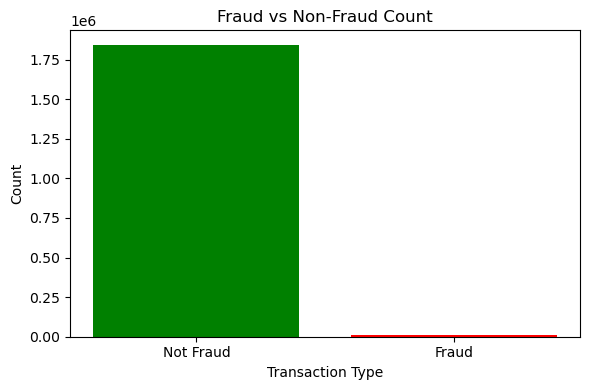

Plot 1 saved successfully!


In [10]:
import os
import matplotlib.pyplot as plt

# Create outputs folder if it doesn't exist
os.makedirs("../outputs", exist_ok=True)

# Convert to Pandas
fraud_pd = fraud_count.toPandas()

# Bar chart - Fraud vs Non-Fraud Count
plt.figure(figsize=(6, 4))
plt.bar(["Not Fraud", "Fraud"], fraud_pd["count"], color=["green", "red"])
plt.title("Fraud vs Non-Fraud Count")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/fraud_vs_nonfraud.png")
plt.show()

print("Plot 1 saved successfully!")

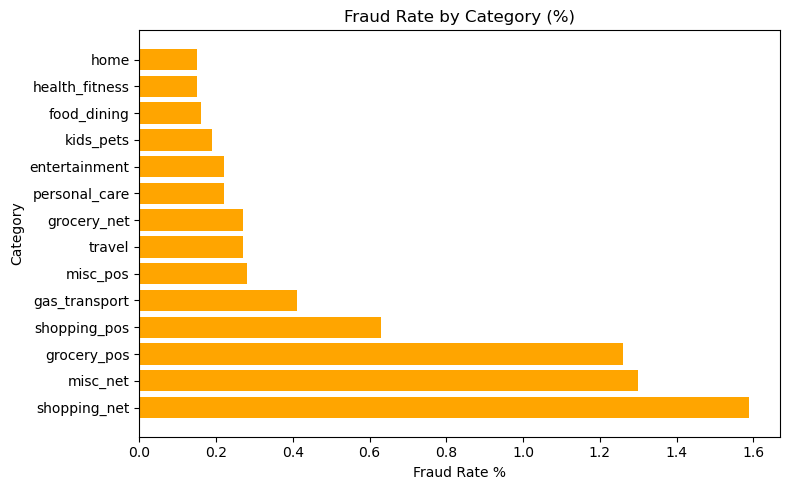

Plot 2 saved successfully!


In [11]:
# Convert to Pandas
category_pd = fraud_by_category.toPandas()

# Bar chart - Fraud Rate by Category
plt.figure(figsize=(8, 5))
plt.barh(category_pd["category"], category_pd["fraud_rate_%"], color="orange")
plt.title("Fraud Rate by Category (%)")
plt.xlabel("Fraud Rate %")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("../outputs/fraud_by_category.png")
plt.show()

print("Plot 2 saved successfully!")

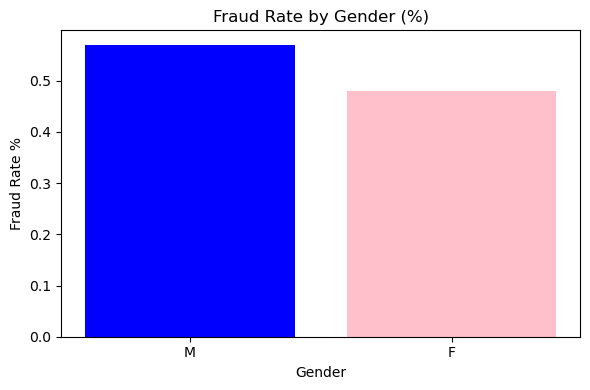

Plot 3 saved successfully!


In [12]:
# Convert to Pandas
gender_pd = fraud_by_gender.toPandas()

# Bar chart - Fraud Rate by Gender
plt.figure(figsize=(6, 4))
plt.bar(gender_pd["gender"], gender_pd["fraud_rate_%"], color=["blue", "pink"])
plt.title("Fraud Rate by Gender (%)")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate %")
plt.tight_layout()
plt.savefig("../outputs/fraud_by_gender.png")
plt.show()

print("Plot 3 saved successfully!")

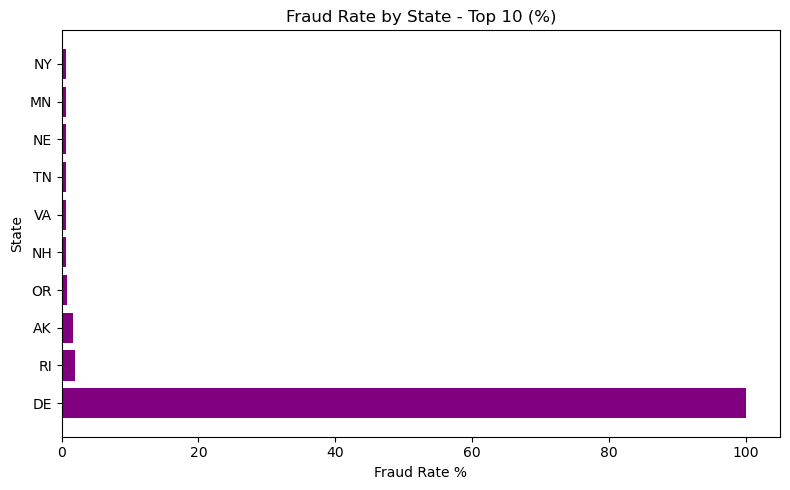

Plot 4 saved successfully!


In [13]:
# Convert to Pandas
state_pd = fraud_by_state.toPandas()

# Top 10 states
top10_state = state_pd.head(10)

# Bar chart - Fraud Rate by State
plt.figure(figsize=(8, 5))
plt.barh(top10_state["state"], top10_state["fraud_rate_%"], color="purple")
plt.title("Fraud Rate by State - Top 10 (%)")
plt.xlabel("Fraud Rate %")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("../outputs/fraud_by_state.png")
plt.show()

print("Plot 4 saved successfully!")

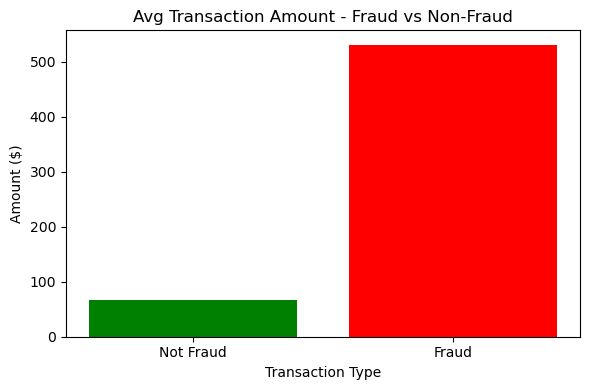

Plot 5 saved successfully!


In [14]:
# Convert to Pandas
amount_pd = avg_amount.toPandas()

# Bar chart - Avg Transaction Amount
plt.figure(figsize=(6, 4))
plt.bar(["Not Fraud", "Fraud"], amount_pd["avg_transaction_amount"], color=["green", "red"])
plt.title("Avg Transaction Amount - Fraud vs Non-Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Amount ($)")
plt.tight_layout()
plt.savefig("../outputs/avg_transaction_amount.png")
plt.show()

print("Plot 5 saved successfully!")

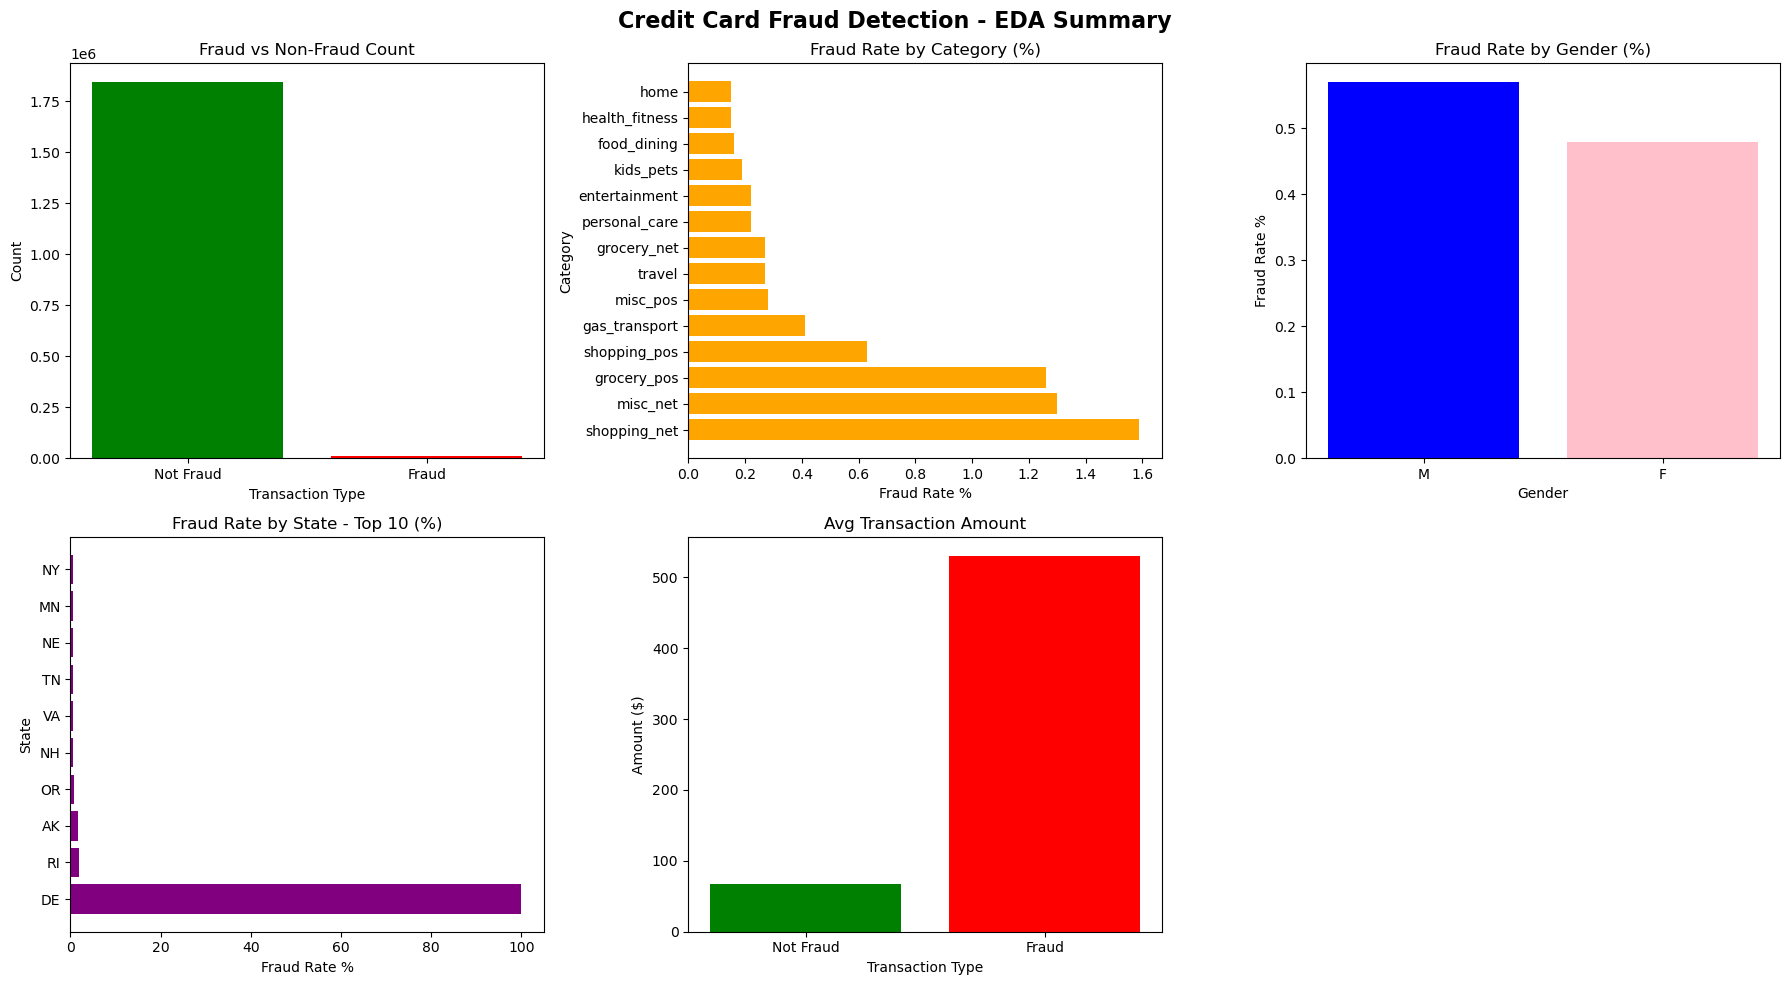

EDA Summary plot saved successfully!


In [15]:
import matplotlib.pyplot as plt

# All plots in one figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 - Fraud vs Non-Fraud Count
axes[0, 0].bar(["Not Fraud", "Fraud"], fraud_pd["count"], color=["green", "red"])
axes[0, 0].set_title("Fraud vs Non-Fraud Count")
axes[0, 0].set_xlabel("Transaction Type")
axes[0, 0].set_ylabel("Count")

# Plot 2 - Fraud Rate by Category
axes[0, 1].barh(category_pd["category"], category_pd["fraud_rate_%"], color="orange")
axes[0, 1].set_title("Fraud Rate by Category (%)")
axes[0, 1].set_xlabel("Fraud Rate %")
axes[0, 1].set_ylabel("Category")

# Plot 3 - Fraud Rate by Gender
axes[0, 2].bar(gender_pd["gender"], gender_pd["fraud_rate_%"], color=["blue", "pink"])
axes[0, 2].set_title("Fraud Rate by Gender (%)")
axes[0, 2].set_xlabel("Gender")
axes[0, 2].set_ylabel("Fraud Rate %")

# Plot 4 - Fraud Rate by State Top 10
axes[1, 0].barh(top10_state["state"], top10_state["fraud_rate_%"], color="purple")
axes[1, 0].set_title("Fraud Rate by State - Top 10 (%)")
axes[1, 0].set_xlabel("Fraud Rate %")
axes[1, 0].set_ylabel("State")

# Plot 5 - Avg Transaction Amount
axes[1, 1].bar(["Not Fraud", "Fraud"], amount_pd["avg_transaction_amount"], color=["green", "red"])
axes[1, 1].set_title("Avg Transaction Amount")
axes[1, 1].set_xlabel("Transaction Type")
axes[1, 1].set_ylabel("Amount ($)")

# Hide empty subplot
axes[1, 2].axis("off")

plt.suptitle("Credit Card Fraud Detection - EDA Summary", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_summary.png")
plt.show()

print("EDA Summary plot saved successfully!")